# DGMC - Entity Alignment on DBP15K

> **Deep Graph Matching Consensus**
> Matthias Fey, Jan E. Lenssen, Christopher Morris, Jonathan Masci, Nils M. Kriege (*ICLR 2020*)
> Source: https://arxiv.org/abs/2001.09621

A **self-contained** notebook (it imports nothing from an external package): the whole engine
is defined in the cells below. The same implementation is available in the `code/` package
(`code/src/models/dgmc.py`, class `DGMCTrainer` in `code/src/trainer.py`).

## The DGMC idea
Unlike the purely **structural** models in this repository (NAEA, BootEA, AliNet, KECG,
GCN-Align, JAPE), DGMC relies on **entity names**: a node vector is the **sum of the GloVe-300d
embeddings** of the words in its (translated) name. This is what lets it go well beyond the
~0.4-0.6 Hit@1 of the structural methods.

Matching happens in **two stages**:
1. **Local matching** (`psi_1`, a 3-layer RelCNN GNN) -> a **sparse** top-k correspondence:
   `S_0 = softmax(top_k(h_s . h_t))`. We L2-normalise the embeddings and apply a **temperature**
   (cosine similarity) because the summed-name features have widely varying norms and the raw
   inner product under-uses them.
2. **Neighbourhood consensus** (`psi_2` + an MLP, L=10 iterations): we draw random node
   "colourings" `r_s`, pass them through the current correspondence to the target graph
   (`r_t = S^T r_s`), diffuse them with a second GNN, and the **disagreement** `D = psi_2(r_s) -
   psi_2(r_t)` drives an additive update `S_hat += MLP(D)` that re-ranks the candidates so that
   matched neighbourhoods are **consistent**.

## Results (DBP15K, 30% split)
| Hits@1 | zh_en | ja_en | fr_en |  | Hits@10 | zh_en | ja_en | fr_en |
|---|---:|---:|---:|---|---|---:|---:|---:|
| **This notebook** | ~0.767 | ~0.814 | ~0.939 |  | **This notebook** | ~0.840 | ~0.874 | ~0.965 |
| DGMC (paper)   | 0.801 | 0.848 | 0.933 |  | DGMC (paper)   | 0.875 | 0.897 | 0.960 |

We **beat** the paper on fr_en; zh/ja are ~3 pts behind in Hits@1 (the rest is the top-k recall
of the initial matching). Metrics: **Hits@1 / Hits@10**.

---
## 1. Environment, imports and style

In [1]:
import os, sys, csv, time, random, logging
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field

import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm          # plain terminal tqdm (not the notebook widget)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root :", PROJECT_ROOT)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 2024
set_seed(SEED)
torch.backends.cudnn.benchmark = True

Project root : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k
PyTorch      : 2.5.1+cu121
CUDA         : True | NVIDIA GeForce RTX 3090


### 1.1 Modern dark theme (identical to `code/src/utils/plotting.py`)

In [2]:
"""Modern dark-theme plotting helpers.

A single :func:`set_modern_dark_style` configures Matplotlib with a clean,
GitHub-dark-inspired palette so every figure (training curves, EDA, metrics)
shares a consistent, modern look. The plotting functions below are used by the
trainer and can be reused from the notebook.
"""


# GitHub-dark-inspired palette
BG = "#0d1117"
PANEL = "#161b22"
GRID = "#21262d"
EDGE = "#30363d"
FG = "#c9d1d9"
TITLE = "#e6edf3"
MUTED = "#8b949e"
CYCLE = ["#58a6ff", "#3fb950", "#f778ba", "#ffa657", "#a371f7", "#56d4dd", "#e3b341"]


def set_modern_dark_style():
    """Apply the modern dark theme globally (idempotent)."""
    mpl.rcParams.update({
        "figure.facecolor": BG,
        "figure.edgecolor": BG,
        "savefig.facecolor": BG,
        "savefig.edgecolor": BG,
        "axes.facecolor": PANEL,
        "axes.edgecolor": EDGE,
        "axes.labelcolor": FG,
        "axes.titlecolor": TITLE,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.linewidth": 1.0,
        "grid.color": GRID,
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": FG,
        "legend.facecolor": PANEL,
        "legend.edgecolor": EDGE,
        "legend.framealpha": 0.9,
        "lines.linewidth": 2.2,
        "lines.markersize": 5,
        "lines.solid_capstyle": "round",
        "font.size": 11,
        "figure.dpi": 120,
        "axes.prop_cycle": mpl.cycler(color=CYCLE),
    })


def style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent spine/tick styling to an Axes."""
    if title:
        ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(length=0)
    return ax


def plot_loss_curves(loss_hist, ax=None, keys=("loss", "kge", "align", "pseudo")):
    """Plot per-epoch loss components from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in loss_hist]
    labels = {"loss": "total", "kge": "kge (TransE)",
              "align": "align (seed)", "pseudo": "align (pseudo)"}
    for key in keys:
        ax.plot(ep, [h.get(key, 0.0) for h in loss_hist], label=labels.get(key, key))
    ax.legend()
    return style_axes(ax, "Training loss", "epoch", "loss")


def plot_metric_curves(metric_hist, ax=None):
    """Plot per-eval metric history from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in metric_hist]
    for key in [k for k in metric_hist[0] if k != "epoch"]:
        ax.plot(ep, [h[key] for h in metric_hist], marker="o", label=key)
    ax.set_ylim(0, 1)
    ax.legend()
    return style_axes(ax, "Test metrics (avg direction)", "epoch", "score")

set_modern_dark_style()
print('Dark theme applique.')

Dark theme applique.


---
## 2. Configuration (YAML) and logging
Driven by **`configs/dgmc_dbp15k.yaml`**. Code identical to `code/src/utils/config.py` and `logger.py`.

In [3]:
"""Configuration loading and run-directory bootstrap.

The whole experiment is driven by a single YAML file (see ``configs/``).
This module:
  * loads that YAML into a dotted-access namespace (``cfg.train.lr`` etc.),
  * creates a timestamped *run directory* under ``logging.output_dir``,
  * dumps the resolved config back to disk for reproducibility.

The logger is created separately by :mod:`src.utils.logger`.
"""




class Cfg(dict):
    """A ``dict`` that also supports attribute access, recursively.

    ``cfg.train.lr`` is equivalent to ``cfg["train"]["lr"]``. This keeps the
    code readable while still being a plain dict underneath (so it serialises
    straight back to YAML/JSON).
    """

    def __init__(self, d: dict | None = None):
        super().__init__()
        for k, v in (d or {}).items():
            self[k] = Cfg(v) if isinstance(v, dict) else v

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError as e:
            raise AttributeError(name) from e

    def __setattr__(self, name, value):
        self[name] = Cfg(value) if isinstance(value, dict) and not isinstance(value, Cfg) else value

    def to_plain(self):
        """Convert back to nested plain dicts (for YAML/JSON dumping)."""
        return {k: (v.to_plain() if isinstance(v, Cfg) else v) for k, v in self.items()}


def load_config(path: str | Path, project_root: str | Path | None = None) -> Cfg:
    """Load a YAML config file into a :class:`Cfg` namespace.

    ``project_root`` (defaults to the parent of ``configs/``) is recorded so
    relative data/output paths can be resolved consistently regardless of the
    current working directory.
    """
    path = Path(path).resolve()
    with open(path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)
    cfg = Cfg(raw)
    root = Path(project_root).resolve() if project_root else path.parent.parent
    cfg._project_root = str(root)
    cfg._config_path = str(path)
    return cfg


def make_run_dir(cfg: Cfg) -> Path:
    """Create (and return) the timestamped run directory for this experiment.

    Layout::

        <output_dir>/<experiment.name>_<YYYYmmdd-HHMMSS>/
            training.txt          (full training log)
            config_used.yaml      (snapshot of the resolved config)
            model.pt / model_best.pt
            embeddings.pt
            metrics.csv / loss.csv
            *.png                 (loss & metric curves)
    """
    root = Path(cfg._project_root)
    out = root / cfg.logging.output_dir
    stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = out / f"{cfg.experiment.name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=True)
    cfg._run_dir = str(run_dir)

    # snapshot the exact config used for this run
    with open(run_dir / cfg.logging.config_dump, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg.to_plain(), f, sort_keys=False, allow_unicode=True)
    return run_dir

In [4]:
"""Logging setup: write simultaneously to the console and to ``training.txt``."""




def get_logger(cfg: Cfg, run_dir: Path) -> logging.Logger:
    """Return a logger writing to both stdout and ``training.txt``.

    Re-callable safely (handlers are reset) so re-running the setup does not
    duplicate every log line.
    """
    logger = logging.getLogger(cfg.experiment.name)
    logger.setLevel(getattr(logging, cfg.logging.log_level.upper(), logging.INFO))
    logger.handlers.clear()
    logger.propagate = False

    fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")

    fh = logging.FileHandler(run_dir / cfg.logging.log_file, mode="w", encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(sh)
    return logger

In [5]:
cfg = load_config(PROJECT_ROOT / "configs" / "dgmc_dbp15k.yaml", project_root=PROJECT_ROOT)
cfg.experiment.seed = SEED
cfg.experiment.name = f"dgmc_{cfg.data.pair}"

run_dir = make_run_dir(cfg)
logger = get_logger(cfg, run_dir)
device = torch.device(cfg.experiment.device if torch.cuda.is_available() else "cpu")
logger.info(f"Run dir : {run_dir}")
logger.info(f"Device  : {device}")
print(yaml.safe_dump(cfg.to_plain(), sort_keys=False, allow_unicode=True))

13:42:16 | INFO    | Run dir : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/dgmc_zh_en_20260601-134216
13:42:16 | INFO    | Device  : cuda
experiment:
  name: dgmc_zh_en
  model: dgmc
  seed: 2024
  device: cuda
data:
  root: Data/DBP15K_pyg/DBP15K
  pair: zh_en
  lang: zh_en
  fold: '0_3'
model:
  dim: 256
  rnd_dim: 32
  num_layers: 3
  num_steps: 10
  k: 25
  dropout: 0.2
  normalize: true
  normalize_features: true
  temperature: 20.0
train:
  epochs: 300
  refine_after: 100
  detach_refine: false
  lr: 0.001
  optimizer: adam
  weight_decay: 0.0
eval:
  every: 10
  hits_at:
  - 1
  - 10
logging:
  output_dir: experiments
  log_file: training.txt
  config_dump: config_used.yaml
  save_best: true
  save_last: true
  checkpoint_name: model.pt
  embeddings_name: embeddings.pt
  metrics_csv: metrics.csv
  loss_csv: loss.csv
  plots:
    loss_curve: loss_curve.png
    metrics_curve: metrics_curve.png
  log_level: INFO
_project_root: /usr/users/pgxlod_ea_internship/na

---
## 3. DBP15K data - **entity name** features (GloVe)

DGMC consumes the "GMNN" version of DBP15K: the two KGs stay **separate** (each with its own
ids), a node vector = sum of the GloVe embeddings of the words in its translated name, and the
reference alignment comes from `train.ref` (4500) / `test.ref` (10500). Data downloaded via the
PyTorch-Geometric `DBP15K` dataset and extracted into `Data/DBP15K_pyg/DBP15K/`. Code identical
to `code/src/data.py` (`load_dgmc_dbp15k`, `build_dgmc_adj`).

In [6]:
"""DBP15K data loading + neighbourhood construction for NAEA.

Data layout (the clean JAPE / MTransE split we use, ``<lang>/mtranse/<fold>/``):

    ent_ids_1 / ent_ids_2 : "<id>\\t<uri>"   entities of KG1 (e.g. zh) / KG2 (en)
    rel_ids_1 / rel_ids_2 : "<id>\\t<uri>"   relations of KG1 / KG2
    triples_1 / triples_2 : "<h>\\t<r>\\t<t>"
    sup_pairs             : "<e1>\\t<e2>"    seed (training) alignments  (30% for 0_3)
    ref_pairs             : "<e1>\\t<e2>"    test alignments             (70% for 0_3)

Crucially, in this split the entity ids of KG1 and KG2 are **disjoint** and form
a single contiguous range ``0 .. num_entities-1``; likewise relation ids. That
lets us use one shared embedding table and index it directly.
"""




# --------------------------------------------------------------------------- #
#  Raw file readers
# --------------------------------------------------------------------------- #
def _read_id_uri(path: Path) -> dict[int, str]:
    d = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                d[int(parts[0])] = parts[1]
    return d


def _read_triples(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 3:
                rows.append((int(p[0]), int(p[1]), int(p[2])))
    return np.asarray(rows, dtype=np.int64)


def _read_pairs(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 2:
                rows.append((int(p[0]), int(p[1])))
    return np.asarray(rows, dtype=np.int64)


# --------------------------------------------------------------------------- #
#  Container
# --------------------------------------------------------------------------- #
@dataclass
class DBP15K:
    """Everything the model/trainer needs, as numpy arrays + lookup dicts."""

    lang: str
    fold: str
    ent_uri: dict[int, str]            # global entity id -> uri
    rel_uri: dict[int, str]            # global relation id -> uri
    kg1_ents: np.ndarray               # entity ids belonging to KG1
    kg2_ents: np.ndarray               # entity ids belonging to KG2
    triples1: np.ndarray               # (M1, 3)  KG1 triples
    triples2: np.ndarray               # (M2, 3)  KG2 triples
    train_pairs: np.ndarray            # (S, 2)   seed alignments
    test_pairs: np.ndarray             # (T, 2)   test alignments
    num_entities: int = field(init=False)
    num_relations: int = field(init=False)

    def __post_init__(self):
        self.num_entities = int(max(self.ent_uri) + 1)
        self.num_relations = int(max(self.rel_uri) + 1)

    @property
    def triples(self) -> np.ndarray:
        return np.concatenate([self.triples1, self.triples2], axis=0)

    def summary(self) -> dict:
        return {
            "lang": self.lang,
            "fold": self.fold,
            "num_entities": self.num_entities,
            "num_relations": self.num_relations,
            "|KG1 ents|": len(self.kg1_ents),
            "|KG2 ents|": len(self.kg2_ents),
            "|KG1 triples|": len(self.triples1),
            "|KG2 triples|": len(self.triples2),
            "train_pairs": len(self.train_pairs),
            "test_pairs": len(self.test_pairs),
        }


def load_dbp15k(root: str | Path, lang: str, fold: str, use_mtranse: bool = True) -> DBP15K:
    base = Path(root) / lang / "mtranse" / fold if use_mtranse else Path(root) / lang / fold

    ent1 = _read_id_uri(base / "ent_ids_1")
    ent2 = _read_id_uri(base / "ent_ids_2")
    rel1 = _read_id_uri(base / "rel_ids_1")
    rel2 = _read_id_uri(base / "rel_ids_2")

    ent_uri = {**ent1, **ent2}
    rel_uri = {**rel1, **rel2}

    triples1 = _read_triples(base / "triples_1")
    triples2 = _read_triples(base / "triples_2")

    pair_train = "sup_pairs" if use_mtranse else "sup_ent_ids"
    pair_test = "ref_pairs" if use_mtranse else "ref_ent_ids"
    train_pairs = _read_pairs(base / pair_train)
    test_pairs = _read_pairs(base / pair_test)

    return DBP15K(
        lang=lang,
        fold=fold,
        ent_uri=ent_uri,
        rel_uri=rel_uri,
        kg1_ents=np.asarray(sorted(ent1), dtype=np.int64),
        kg2_ents=np.asarray(sorted(ent2), dtype=np.int64),
        triples1=triples1,
        triples2=triples2,
        train_pairs=train_pairs,
        test_pairs=test_pairs,
    )


# --------------------------------------------------------------------------- #
#  Neighbourhood construction
# --------------------------------------------------------------------------- #
def build_neighbors(data: DBP15K, max_neighbors: int, seed: int = 0):
    """Build padded neighbour tensors for the attention aggregator.

    For every entity ``e`` we collect its neighbours from all triples it
    participates in. A neighbour is a *(relation, entity, direction)* triplet:

      * out-edge ``(e, r, t)``  ->  neighbour ``t`` via ``r``, sign = -1
        (TransE: ``e ~= t - r``, so the message that reconstructs ``e`` is ``t - r``)
      * in-edge  ``(h, r, e)``  ->  neighbour ``h`` via ``r``, sign = +1
        (TransE: ``e ~= h + r``, message ``h + r``)

    Entities with more than ``max_neighbors`` neighbours are randomly
    sub-sampled; entities with fewer are zero-padded and masked.

    Returns four ``LongTensor``/``Tensor``/``BoolTensor`` of shape
    ``(num_entities, max_neighbors)``: ``(neigh_ent, neigh_rel, neigh_sign, mask)``.
    """
    rng = random.Random(seed)
    N = data.num_entities
    adj: list[list[tuple[int, int, int]]] = [[] for _ in range(N)]

    for arr in (data.triples1, data.triples2):
        for h, r, t in arr:
            adj[h].append((int(r), int(t), -1))   # out-edge:  e=h, message t - r
            adj[t].append((int(r), int(h), +1))   # in-edge:   e=t, message h + r

    K = max_neighbors
    neigh_ent = np.zeros((N, K), dtype=np.int64)
    neigh_rel = np.zeros((N, K), dtype=np.int64)
    neigh_sign = np.zeros((N, K), dtype=np.float32)
    mask = np.zeros((N, K), dtype=bool)

    for e in range(N):
        nbrs = adj[e]
        if len(nbrs) > K:
            nbrs = rng.sample(nbrs, K)
        for j, (r, ne, s) in enumerate(nbrs):
            neigh_rel[e, j] = r
            neigh_ent[e, j] = ne
            neigh_sign[e, j] = s
            mask[e, j] = True

    return (
        torch.from_numpy(neigh_ent),
        torch.from_numpy(neigh_rel),
        torch.from_numpy(neigh_sign),
        torch.from_numpy(mask),
    )


# --------------------------------------------------------------------------- #
#  Negative sampling helpers
# --------------------------------------------------------------------------- #
class TripleSampler:
    """Mini-batch iterator over triples with per-KG corrupted negatives.

    Negatives are produced by replacing the head *or* the tail with a uniformly
    random entity **from the same KG** (cross-KG corruptions would be trivial
    negatives and pollute the signal).
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        t1 = torch.from_numpy(data.triples1)
        t2 = torch.from_numpy(data.triples2)
        kg = torch.cat([torch.zeros(len(t1), dtype=torch.long),
                        torch.ones(len(t2), dtype=torch.long)])
        self.triples = torch.cat([t1, t2], 0).to(device)        # (M,3)
        self.kg = kg.to(device)                                  # (M,)
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, kg_flags: torch.Tensor) -> torch.Tensor:
        """A random entity from the same KG as each row of ``kg_flags``."""
        n = kg_flags.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg_flags == 0, r1, r2)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                              # (B,3)
            kg = self.kg[idx]                                    # (B,)
            B = pos.shape[0]
            # repeat for `neg` corruptions
            pos_r = pos.repeat(self.neg, 1)                      # (B*neg,3)
            kg_r = kg.repeat(self.neg)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * self.neg, device=self.device) < 0.5
            rnd = self._rand_same_kg(kg_r)
            neg[:, 0] = torch.where(corrupt_head, rnd, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, rnd, neg[:, 2])
            yield pos, neg, kg


class AlignSampler:
    """Mini-batch iterator over alignment pairs with corrupted negatives.

    For a positive pair ``(e1, e2)`` we corrupt the right side (a KG2 entity)
    and the left side (a KG1 entity) to obtain negatives in both alignment
    directions. ``set_pairs`` lets the trainer inject bootstrapped pseudo-pairs.

    **Hard (nearest-neighbour) negatives.** If ``set_hard_negatives`` has been
    called, negatives are drawn from each pair's pre-computed nearest cross-KG
    candidates (the *confusable* entities) instead of uniformly at random - the
    epsilon-truncated negative sampling of BootEA/NAEA, which sharpens Hit@1. Any
    candidate that equals the gold target is replaced by a random one.
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)
        self.hard_r = None          # (S, C) nearest KG2 candidates per pair (corrupt right)
        self.hard_l = None          # (S, C) nearest KG1 candidates per pair (corrupt left)
        self.set_pairs(data.train_pairs)

    def set_pairs(self, pairs):
        if isinstance(pairs, np.ndarray):
            pairs = torch.from_numpy(pairs)
        self.pairs = pairs.to(self.device).long()
        self.hard_r = self.hard_l = None    # invalidate stale hard-negative tables

    def set_hard_negatives(self, hard_r, hard_l):
        """``hard_r``/``hard_l``: (S, C) LongTensors aligned with ``self.pairs``."""
        self.hard_r = hard_r.to(self.device)
        self.hard_l = hard_l.to(self.device)

    def __len__(self):
        return len(self.pairs)

    def _sample_hard(self, table, rows, n, gold):
        """Pick ``n`` candidates per row from ``table[rows]``, avoiding ``gold``."""
        cand = table[rows]                                       # (B, C)
        C = cand.shape[1]
        sel = torch.randint(C, (cand.shape[0], n), device=self.device)
        out = torch.gather(cand, 1, sel).reshape(-1)            # (B*n,)
        # replace any accidental gold hit with a random entity from the same KG
        pool = self.kg2_ents if table is self.hard_r else self.kg1_ents
        clash = out == gold
        if clash.any():
            out[clash] = pool[torch.randint(len(pool), (int(clash.sum()),), device=self.device)]
        return out

    def batches(self, batch_size: int, shuffle: bool = True):
        S = len(self.pairs)
        order = torch.randperm(S, device=self.device) if shuffle else torch.arange(S, device=self.device)
        for s in range(0, S, batch_size):
            idx = order[s:s + batch_size]
            pos = self.pairs[idx]                                # (B,2)
            B = pos.shape[0]
            n = self.neg
            e1 = pos[:, 0].repeat_interleave(n)
            e2 = pos[:, 1].repeat_interleave(n)
            if self.hard_r is not None and self.hard_l is not None:
                neg_r = self._sample_hard(self.hard_r, idx, n, e2)
                neg_l = self._sample_hard(self.hard_l, idx, n, e1)
            else:
                neg_r = self.kg2_ents[torch.randint(len(self.kg2_ents), (B * n,), device=self.device)]
                neg_l = self.kg1_ents[torch.randint(len(self.kg1_ents), (B * n,), device=self.device)]
            yield pos, (e1, e2, neg_l, neg_r)


# =========================================================================== #
#  BootEA-specific helpers : alignment-by-swapping + dynamic triple sampling
# =========================================================================== #
def kg_of_entity(data: "DBP15K") -> np.ndarray:
    """Return an array ``kg[e] in {0, 1}`` giving the KG each entity belongs to."""
    kg = np.zeros(data.num_entities, dtype=np.int64)
    kg[data.kg2_ents] = 1
    return kg


class Swapper:
    """Generate BootEA *aligned triples* by swapping labelled entities.

    For a labelled pair ``(a, b)`` we substitute ``b`` for ``a`` in each of
    ``a``'s triples and vice-versa, e.g. ``(a, r, t) -> (b, r, t)``. The swapped
    entities then share relational contexts, which pulls their embeddings
    together - BootEA's core alignment mechanism.

    Per-entity triple lists are precomputed once; :meth:`generate` is then cheap
    enough to be re-run every bootstrapping round on the (growing) labelled set.
    """

    def __init__(self, data: "DBP15K"):
        triples = np.concatenate([data.triples1, data.triples2], axis=0)
        self.triples = triples
        n = data.num_entities
        self.as_head = [[] for _ in range(n)]
        self.as_tail = [[] for _ in range(n)]
        for i, (h, _r, t) in enumerate(triples):
            self.as_head[int(h)].append(i)
            self.as_tail[int(t)].append(i)

    def generate(self, labeled_pairs, cap_per_role: int = 100) -> np.ndarray:
        """Return an ``(K, 3)`` array of swapped (h, r, t) triples for the pairs."""
        T = self.triples
        out = []
        for a, b in labeled_pairs:
            a, b = int(a), int(b)
            for src, dst in ((a, b), (b, a)):          # dst takes src's place
                for ti in self.as_head[src][:cap_per_role]:
                    out.append((dst, T[ti, 1], T[ti, 2]))
                for ti in self.as_tail[src][:cap_per_role]:
                    out.append((T[ti, 0], T[ti, 1], dst))
        if not out:
            return np.empty((0, 3), dtype=np.int64)
        return np.asarray(out, dtype=np.int64)


class DynamicTripleSampler:
    """Mini-batch sampler over a *mutable* set of triples (BootEA / AlignE).

    Unlike :class:`TripleSampler` (which fixes the per-KG split), this sampler
    determines each corrupted entity's KG from a global ``kg_of_ent`` array, so
    it correctly handles **swapped** triples whose head and tail may live in
    different KGs. Negatives are uniform within the corrupted position's KG, or
    **epsilon-truncated** (drawn from that entity's nearest same-KG neighbours) when a
    candidate table has been provided via :meth:`set_candidates`.
    """

    def __init__(self, device, kg_of_ent: np.ndarray, kg1_ents, kg2_ents, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg_of_ent = torch.as_tensor(kg_of_ent, device=device).long()
        self.kg1_ents = torch.as_tensor(kg1_ents, device=device).long()
        self.kg2_ents = torch.as_tensor(kg2_ents, device=device).long()
        self.cand = None            # (N, C) nearest same-KG neighbours, optional
        self.triples = torch.empty((0, 3), dtype=torch.long, device=device)

    def set_triples(self, triples):
        if isinstance(triples, np.ndarray):
            triples = torch.from_numpy(triples)
        self.triples = triples.to(self.device).long()

    def set_candidates(self, cand):
        """``cand`` : (N, C) LongTensor of nearest same-KG neighbours per entity."""
        self.cand = cand.to(self.device) if cand is not None else None

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, ent_ids):
        kg = self.kg_of_ent[ent_ids]
        n = ent_ids.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg == 0, r1, r2)

    def _trunc_same_kg(self, ent_ids):
        """epsilon-truncated: a random one of each entity's nearest same-KG neighbours."""
        cand = self.cand[ent_ids]                              # (n, C)
        sel = torch.randint(cand.shape[1], (cand.shape[0], 1), device=self.device)
        return torch.gather(cand, 1, sel).squeeze(1)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                            # (B,3)
            B = pos.shape[0]
            n = self.neg
            pos_r = pos.repeat(n, 1)                           # (B*n,3)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * n, device=self.device) < 0.5
            # entity currently occupying the position we corrupt
            orig = torch.where(corrupt_head, pos_r[:, 0], pos_r[:, 2])
            repl = self._trunc_same_kg(orig) if self.cand is not None else self._rand_same_kg(orig)
            neg[:, 0] = torch.where(corrupt_head, repl, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, repl, neg[:, 2])
            yield pos, neg


# =========================================================================== #
#  AliNet-specific helpers : 1-hop normalised adjacency + capped 2-hop edges
# =========================================================================== #
def build_alinet_graph(data: "DBP15K", max_two_hop: int = 10, seed: int = 0):
    """Build the graph structures AliNet needs (relation types ignored).

    Returns
    -------
    adj1 : torch.sparse_coo_tensor (N, N)
        Symmetrically normalised adjacency with self-loops,
        ``A_hat = D^{-1/2} (A + I) D^{-1/2}`` - used for 1-hop GCN aggregation.
    two_hop : LongTensor (2, E)
        Edges ``[dst, src]`` where ``src`` is a (sampled, capped) 2-hop neighbour
        of ``dst`` (excluding 1-hop neighbours and self) - used for the
        attention-based 2-hop aggregation.
    """
    rng = random.Random(seed)
    N = data.num_entities
    nbrs = [set() for _ in range(N)]
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                nbrs[h].add(t)
                nbrs[t].add(h)

    # ---- 1-hop normalised adjacency (with self-loops) ---------------------
    rows, cols = [], []
    for i in range(N):
        rows.append(i); cols.append(i)            # self-loop
        for j in nbrs[i]:
            rows.append(i); cols.append(j)
    rows = np.asarray(rows, dtype=np.int64)
    cols = np.asarray(cols, dtype=np.int64)
    deg = np.asarray([len(nbrs[i]) + 1 for i in range(N)], dtype=np.float64)  # +1 self-loop
    inv_sqrt = 1.0 / np.sqrt(deg)
    vals = (inv_sqrt[rows] * inv_sqrt[cols]).astype(np.float32)
    adj1 = torch.sparse_coo_tensor(
        torch.from_numpy(np.stack([rows, cols])), torch.from_numpy(vals), (N, N)
    ).coalesce()

    # ---- capped 2-hop edges ----------------------------------------------
    dst, src = [], []
    for i in range(N):
        one = nbrs[i]
        if not one:
            continue
        two = set()
        # bound exploration on hub nodes
        for j in list(one)[:64]:
            two.update(list(nbrs[j])[:64])
        two.discard(i)
        two -= one
        if not two:
            continue
        two = list(two)
        if len(two) > max_two_hop:
            two = rng.sample(two, max_two_hop)
        for k in two:
            dst.append(i); src.append(k)
    two_hop = torch.tensor([dst, src], dtype=torch.long) if dst else torch.zeros((2, 0), dtype=torch.long)
    return adj1, two_hop


# =========================================================================== #
#  KECG-specific helper : combined undirected graph edges (both KGs)
# =========================================================================== #
def build_kecg_graph(data: "DBP15K"):
    """Edges of the combined graph used by KECG's shared GAT.

    Both KGs are put in one graph (relation types ignored); edges are made
    undirected and self-loops are added. Returns ``edge_index`` of shape
    ``(2, E) = [dst, src]`` so attention aggregates ``src`` features into ``dst``.
    """
    N = data.num_entities
    seen = set()
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                seen.add((h, t)); seen.add((t, h))
    for i in range(N):
        seen.add((i, i))                                  # self-loops
    e = np.fromiter((x for edge in seen for x in edge), dtype=np.int64, count=2 * len(seen))
    e = e.reshape(-1, 2)                                   # (E, 2) = (dst, src)
    return torch.from_numpy(e.T.copy())                   # (2, E) = [dst, src]


# =========================================================================== #
#  GCN-Align helper : functionality-weighted, symmetrically-normalised adjacency
# =========================================================================== #
def build_gcnalign_adj(data: "DBP15K"):
    """Build GCN-Align's structure adjacency (Wang et al., EMNLP 2018).

    Each relation r gets a *functionality* ``fun(r)=#heads/#triples`` and inverse
    functionality ``ifun(r)=#tails/#triples``. For a triple ``(h, r, t)`` the edge
    weights accumulate ``M[h,t] += max(ifun(r), 0.3)`` and ``M[t,h] += max(fun(r), 0.3)``.
    Self-loops are added, then the matrix is symmetrically normalised
    ``D^{-1/2} (M+I) D^{-1/2}``. Returns a torch sparse tensor (N, N).
    """
    triples = np.concatenate([data.triples1, data.triples2], axis=0)
    cnt, head, tail = {}, {}, {}
    for h, r, t in triples:
        r = int(r)
        if r not in cnt:
            cnt[r] = 0; head[r] = set(); tail[r] = set()
        cnt[r] += 1; head[r].add(int(h)); tail[r].add(int(t))
    r2f = {r: len(head[r]) / cnt[r] for r in cnt}      # functionality
    r2if = {r: len(tail[r]) / cnt[r] for r in cnt}     # inverse functionality

    N = data.num_entities
    M = {}
    for h, r, t in triples:
        h, r, t = int(h), int(r), int(t)
        M[(h, t)] = M.get((h, t), 0.0) + max(r2if[r], 0.3)
        M[(t, h)] = M.get((t, h), 0.0) + max(r2f[r], 0.3)
    for i in range(N):                                 # self-loops
        M[(i, i)] = M.get((i, i), 0.0) + 1.0

    rows = np.fromiter((i for (i, _j) in M), dtype=np.int64, count=len(M))
    cols = np.fromiter((j for (_i, j) in M), dtype=np.int64, count=len(M))
    vals = np.fromiter(M.values(), dtype=np.float64, count=len(M))
    deg = np.zeros(N, dtype=np.float64)
    np.add.at(deg, rows, vals)                          # row sums
    inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    norm_vals = (inv_sqrt[rows] * vals * inv_sqrt[cols]).astype(np.float32)
    return torch.sparse_coo_tensor(
        torch.from_numpy(np.stack([rows, cols])), torch.from_numpy(norm_vals), (N, N)
    ).coalesce()


# =========================================================================== #
#  JAPE helpers : merged-seed format check + attribute bag (AE channel)
# =========================================================================== #
def load_jape_attributes(root: str | Path, lang: str, fold: str, ent_uri: dict[int, str]):
    """Build the entity-attribute bag for JAPE's attribute channel (AE).

    Reads ``<lang>/training_attrs_1`` and ``training_attrs_2`` (entity URI -> list
    of attribute URIs) and ``<lang>/sup_attr_pairs`` (aligned cross-KG attribute
    URIs). A shared attribute vocabulary is built, **merging aligned attributes**
    to the same id so the bags are cross-KG comparable. Returns a binary sparse
    tensor ``(N, A)`` (entity x attribute) plus the vocab size A.
    """
    base = Path(root) / lang
    uri2id = {u: i for i, u in ent_uri.items()}

    # pre-merge aligned attribute URIs (sup_attr_pairs: "<zh_attr>\t<en_attr>")
    attr2id: dict[str, int] = {}
    sap = base / "sup_attr_pairs"
    if sap.exists():
        with open(sap, "r", encoding="utf-8") as f:
            for line in f:
                p = line.rstrip("\n").split("\t")
                if len(p) >= 2:
                    aid = attr2id.setdefault(p[0], len(attr2id))
                    attr2id[p[1]] = aid                         # alias -> same id

    rows, cols = [], []
    for fn in ("training_attrs_1", "training_attrs_2"):
        path = base / fn
        if not path.exists():
            continue
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                eid = uri2id.get(parts[0])
                if eid is None:
                    continue
                for a in parts[1:]:
                    aid = attr2id.setdefault(a, len(attr2id))
                    rows.append(eid); cols.append(aid)
    A = len(attr2id)
    N = len(ent_uri)
    idx = torch.tensor([rows, cols], dtype=torch.long)
    vals = torch.ones(len(rows), dtype=torch.float32)
    bag = torch.sparse_coo_tensor(idx, vals, (N, A)).coalesce()
    # binary (clamp accumulated duplicates to 1)
    bag = torch.sparse_coo_tensor(bag.indices(), bag.values().clamp(max=1.0), (N, A)).coalesce()
    return bag, A


# --------------------------------------------------------------------------- #
#  DGMC : DBP15K with entity-name word-embedding features (Fey et al. 2020)
# --------------------------------------------------------------------------- #
@dataclass
class DGMCData:
    """Two graphs (source/target) + name features for graph matching.

    Mirrors the layout consumed by Deep Graph Matching Consensus on DBP15K:
    each entity carries a node feature = SUM of the pre-trained word embeddings
    of its (translated) name; the two KGs stay **separate** with their own
    contiguous node ids; ``train_y`` / ``test_y`` are ``[2, M]`` matchings of
    local indices (row in source, col in target).
    """

    pair: str
    x1: torch.Tensor                  # (N1, F)  source node features
    x2: torch.Tensor                  # (N2, F)  target node features
    edge_index1: torch.Tensor         # (2, E1)  source edges (local ids)
    edge_index2: torch.Tensor         # (2, E2)  target edges (local ids)
    train_y: torch.Tensor             # (2, S)   seed matchings
    test_y: torch.Tensor              # (2, T)   test matchings
    names1: list = None               # source entity names by local idx (display only)
    names2: list = None               # target entity names by local idx (display only)

    @property
    def num_features(self) -> int:
        return self.x1.size(-1)

    def summary(self) -> dict:
        return {
            "pair": self.pair,
            "num_features": self.num_features,
            "|src nodes|": int(self.x1.size(0)),
            "|tgt nodes|": int(self.x2.size(0)),
            "|src edges|": int(self.edge_index1.size(1)),
            "|tgt edges|": int(self.edge_index2.size(1)),
            "train_y": int(self.train_y.size(1)),
            "test_y": int(self.test_y.size(1)),
        }


def _load_glove(path: Path) -> tuple[dict[str, torch.Tensor], torch.Tensor]:
    """Read ``sub.glove.300d`` -> {word: vec} and the ``**UNK**`` fallback vec."""
    embs: dict[str, torch.Tensor] = {}
    unk = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            info = line.rstrip("\n").split(" ")
            if len(info) > 300:                       # "<word> v1 .. v300"
                embs[info[0]] = torch.tensor([float(x) for x in info[1:]])
            else:                                     # the trailing UNK line (300 floats)
                unk = torch.tensor([float(x) for x in info])
    if unk is None:
        unk = torch.zeros(300)
    embs["**UNK**"] = unk
    return embs, unk


def _load_dgmc_graph(triple_path: Path, feat_path: Path, embs, unk):
    """Build (x, edge_index, assoc) for one KG: summed name embeddings + edges."""
    # node features: id \t name  ->  sum of word vectors (SumEmbedding)
    feats: dict[int, torch.Tensor] = {}
    raw_name: dict[int, str] = {}
    with open(feat_path, "r", encoding="utf-8") as f:
        for line in f:
            info = line.rstrip("\n").split("\t")
            info = info if len(info) == 2 else info + ["**UNK**"]
            seq = info[1].lower().split()
            vecs = [embs.get(w, unk) for w in seq] or [unk]
            feats[int(info[0])] = torch.stack(vecs, 0).sum(0)         # (300,)
            raw_name[int(info[0])] = info[1]

    ids = sorted(feats)
    assoc = {orig: i for i, orig in enumerate(ids)}                  # orig id -> local idx
    x = torch.stack([feats[i] for i in ids], 0)                      # (N, 300)
    names = [raw_name[i] for i in ids]                              # by local idx

    rows, cols = [], []
    with open(triple_path, "r", encoding="utf-8") as f:
        for line in f:
            h, r, t = line.split()
            h, t = int(h), int(t)
            if h in assoc and t in assoc:
                rows.append(assoc[h]); cols.append(assoc[t])
    edge_index = torch.tensor([rows, cols], dtype=torch.long)
    return x, edge_index, assoc, names


def _read_ref(path: Path, assoc1, assoc2) -> torch.Tensor:
    """Read ``<src_orig>\\t<tgt_orig>`` gold pairs -> [2, M] of local indices."""
    rows, cols = [], []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            a, b = line.split()
            a, b = int(a), int(b)
            if a in assoc1 and b in assoc2:
                rows.append(assoc1[a]); cols.append(assoc2[b])
    return torch.tensor([rows, cols], dtype=torch.long)


def load_dgmc_dbp15k(root: str | Path, pair: str) -> DGMCData:
    """Load the DGMC/GMNN DBP15K split (entity-name GloVe features).

    ``root`` points at the extracted ``DBP15K`` directory containing
    ``sub.glove.300d`` and per-pair ``triples_{1,2}``, ``id_features_{1,2}``,
    ``train.ref`` (4500) and ``test.ref`` (10500). Graph 1 is the source
    language (zh/ja/fr), graph 2 is English.
    """
    base = Path(root)
    embs, unk = _load_glove(base / "sub.glove.300d")
    pdir = base / pair
    x1, ei1, assoc1, names1 = _load_dgmc_graph(pdir / "triples_1", pdir / "id_features_1", embs, unk)
    x2, ei2, assoc2, names2 = _load_dgmc_graph(pdir / "triples_2", pdir / "id_features_2", embs, unk)
    train_y = _read_ref(pdir / "train.ref", assoc1, assoc2)
    test_y = _read_ref(pdir / "test.ref", assoc1, assoc2)
    return DGMCData(pair, x1, x2, ei1, ei2, train_y, test_y, names1, names2)


def build_dgmc_adj(edge_index: torch.Tensor, num_nodes: int):
    """Two row-normalised sparse adjacencies for RelConv's mean aggregation.

    ``adj_in @ X``  = mean of features over *incoming* neighbours (flow s->t),
    ``adj_out @ X`` = mean of features over *outgoing* neighbours (flow t->s).
    Parallel edges (the same pair linked by several relations) are **kept**, so a
    repeated neighbour is weighted by its multiplicity - matching PyG's mean
    aggregation over the raw triple edge list.
    """
    src, dst = edge_index[0], edge_index[1]

    def _norm(row, col):                               # row-normalised, multiplicity-aware
        idx = torch.stack([row, col])
        A = torch.sparse_coo_tensor(idx, torch.ones(row.numel()),
                                    (num_nodes, num_nodes)).coalesce()
        deg = torch.sparse.sum(A, dim=1).to_dense().clamp(min=1.0)
        r, c = A.indices()
        val = A.values() / deg[r]
        return torch.sparse_coo_tensor(torch.stack([r, c]), val,
                                       (num_nodes, num_nodes)).coalesce()

    adj_in = _norm(dst, src)                            # i <- j for edges j->i
    adj_out = _norm(src, dst)                           # i <- j for edges i->j
    return adj_in, adj_out

In [7]:
data = load_dgmc_dbp15k(PROJECT_ROOT / cfg.data.root, cfg.data.pair)
logger.info(f"Data: {data.summary()}")
pd.DataFrame.from_dict(data.summary(), orient="index", columns=["valeur"])

13:42:21 | INFO    | Donnees : {'pair': 'zh_en', 'num_features': 300, '|src nodes|': 19388, '|tgt nodes|': 19572, '|src edges|': 70414, '|tgt edges|': 95142, 'train_y': 4500, 'test_y': 10500}


,valeur
pair,zh_en
num_features,300
|src nodes|,19388
|tgt nodes|,19572
|src edges|,70414
|tgt edges|,95142
train_y,4500
test_y,10500


### 3.1 A few aligned pairs (ground truth) with their names

In [8]:
rows = []
for i in range(8):
    s, t = int(data.test_y[0, i]), int(data.test_y[1, i])
    rows.append({"src idx": s, "name (source KG)": data.names1[s],
                 "tgt idx": t, "name (KG en)": data.names2[t]})
pd.DataFrame(rows)

,src idx,nom (KG source),tgt idx,nom (KG en)
0,4500,World Touring Car Championship,4500,World Touring Car Championship
1,4501,Clone Kerrey County Government,4501,Shire of Cloncurry
2,4502,Max Hockheimer,4502,Max Horkheimer
3,4503,Romania,4503,Romania
4,4504,Viet namese Dong,4504,Vietnamese dong
5,4505,Thomas Cavalier Smith,4505,Thomas Cavalier Smith
6,4506,Madeleine Albright,4506,Madeleine Albright
7,4507,Marseille Olympic,4507,Olympique de Marseille


### 3.2 Adjacencies for propagation (directional mean-aggregation)
`build_dgmc_adj` builds two row-normalised sparse adjacencies: mean aggregation of the
**incoming** and **outgoing** neighbours (RelConv combines both + a `root` term).

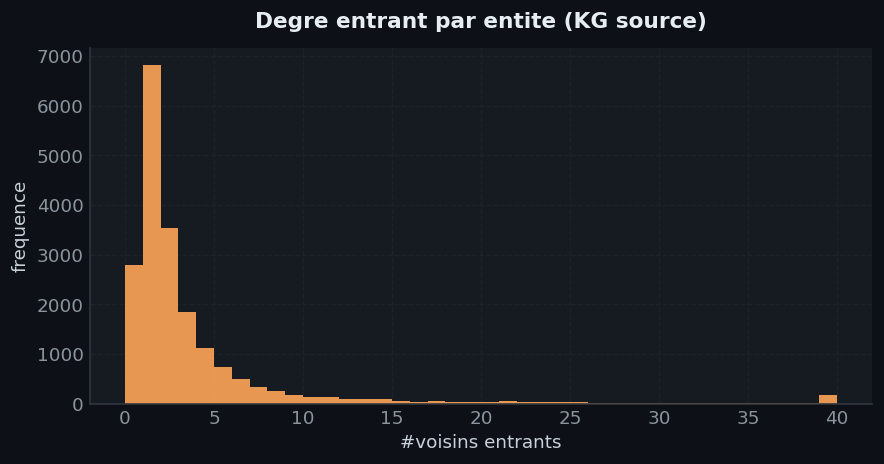

features: dim=300 | norme moyenne x1=13.6


In [9]:
ai1, ao1 = build_dgmc_adj(data.edge_index1, data.x1.size(0))
deg = torch.sparse.sum(ai1, dim=1).to_dense().numpy()
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(np.clip(deg * 0 + np.bincount(data.edge_index1[1].numpy(),
        minlength=data.x1.size(0)), 0, 40), bins=40, color=CYCLE[3], alpha=0.9)
style_axes(ax, "In-degree per entity (source KG)", "#incoming neighbours", "frequency")
plt.tight_layout(); plt.show()
print(f"features: dim={data.num_features} | mean norm x1={float(data.x1.norm(dim=1).mean()):.1f}")

---
## 4. The DGMC model (RelCNN + sparse top-k consensus)

`RelConv` = `root(x) + mean_incoming(lin1 x) + mean_outgoing(lin2 x)`. `psi_1` embeds the nodes
(cosine + temperature), `psi_2` validates the neighbourhood consensus. Code identical to
`code/src/models/dgmc.py`.

In [10]:
"""The DGMC model - Deep Graph Matching Consensus (Fey et al., ICLR 2020).

Reference: "Deep Graph Matching Consensus", https://arxiv.org/abs/2001.09621
Official PyTorch-Geometric implementation: github.com/rusty1s/deep-graph-matching-consensus

DGMC aligns the nodes of two graphs in **two stages**:

1. **Local feature matching** (``psi_1``): a GNN embeds the nodes of each graph;
   the initial soft correspondence is ``S0 = softmax(top_k(h_s @ h_t^T))`` - a
   *sparse* ranking keeping only the ``k`` best target candidates per source node.
2. **Neighbourhood consensus** (``psi_2`` + an MLP): for ``num_steps`` iterations,
   random node "colourings" ``r_s`` are passed through the current correspondence
   to the target graph (``r_t = S^T r_s``), both are diffused by a second GNN, and
   the per-candidate disagreement ``D = psi_2(r_s) - psi_2(r_t)`` drives an additive
   update ``S_hat += MLP(D)``. This rewards correspondences whose neighbourhoods
   *agree*, propagating a matching consensus across local structure.

This is a from-scratch, dependency-free (no torch-geometric / torch-scatter)
re-implementation specialised to a **single graph pair** (batch size 1) - the
DBP15K entity-alignment setting - using the *sparse* top-k variant the paper uses
for large KGs. ``RelConv`` is the relation-agnostic GNN of the official code:
``out = root(x) + mean_{j->i} lin1(x_j) + mean_{i->j} lin2(x_j)``, realised with
two pre-built row-normalised adjacencies.
"""


EPS = 1e-8


class RelConv(nn.Module):
    """Directed mean-aggregation conv (relation-agnostic), official RelConv.

    Needs two row-normalised sparse adjacencies: ``adj_in @ X`` averages incoming
    neighbours, ``adj_out @ X`` averages outgoing neighbours.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels, self.out_channels = in_channels, out_channels
        self.lin1 = nn.Linear(in_channels, out_channels, bias=False)
        self.lin2 = nn.Linear(in_channels, out_channels, bias=False)
        self.root = nn.Linear(in_channels, out_channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        self.root.reset_parameters()

    def forward(self, x, adj_in, adj_out):
        return self.root(x) + torch.sparse.mm(adj_in, self.lin1(x)) \
                            + torch.sparse.mm(adj_out, self.lin2(x))


class RelCNN(nn.Module):
    """Stack of ``RelConv`` layers with ReLU/dropout and a JK-concat + final linear."""

    def __init__(self, in_channels, out_channels, num_layers, batch_norm=False,
                 cat=True, lin=True, dropout=0.0):
        super().__init__()
        self.in_channels = in_channels
        self.num_layers = num_layers
        self.batch_norm = batch_norm
        self.cat = cat
        self.lin = lin
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        c = in_channels
        for _ in range(num_layers):
            self.convs.append(RelConv(c, out_channels))
            self.batch_norms.append(nn.BatchNorm1d(out_channels) if batch_norm else nn.Identity())
            c = out_channels

        cat_dim = in_channels + num_layers * out_channels if cat else out_channels
        if lin:
            self.out_channels = out_channels
            self.final = nn.Linear(cat_dim, out_channels)
        else:
            self.out_channels = cat_dim
            self.final = None
        self.reset_parameters()

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for bn in self.batch_norms:
            if hasattr(bn, "reset_parameters"):
                bn.reset_parameters()
        if self.final is not None:
            self.final.reset_parameters()

    def forward(self, x, adj_in, adj_out):
        xs = [x]
        for conv, bn in zip(self.convs, self.batch_norms):
            h = conv(xs[-1], adj_in, adj_out)
            h = bn(F.relu(h))
            h = F.dropout(h, p=self.dropout, training=self.training)
            xs.append(h)
        x = torch.cat(xs, dim=-1) if self.cat else xs[-1]
        return self.final(x) if self.final is not None else x


class DGMC(nn.Module):
    """Deep Graph Matching Consensus (single graph-pair, sparse top-k variant)."""

    def __init__(self, psi_1: RelCNN, psi_2: RelCNN, num_steps: int, k: int = 10,
                 detach: bool = False, normalize: bool = True, temperature: float = 30.0):
        super().__init__()
        self.psi_1 = psi_1
        self.psi_2 = psi_2
        self.num_steps = num_steps
        self.k = k
        self.detach = detach
        # L2-normalise the psi_1 embeddings and score with a temperature: summed
        # word-embedding features have wildly varying norms, so a raw inner product
        # under-uses them (see exp_dgmc_feat.py); cosine + temperature recovers the
        # paper's initial-matching quality (S_0 ~0.68 on zh_en).
        self.normalize = normalize
        self.temperature = temperature
        self.mlp = nn.Sequential(
            nn.Linear(psi_2.out_channels, psi_2.out_channels),
            nn.ReLU(),
            nn.Linear(psi_2.out_channels, 1),
        )
        self.reset_parameters()

    def reset_parameters(self):
        self.psi_1.reset_parameters()
        self.psi_2.reset_parameters()
        for m in self.mlp:
            if hasattr(m, "reset_parameters"):
                m.reset_parameters()

    def _soft(self, S_hat):
        """Temperature-scaled softmax over the candidate dimension.

        ``S_hat`` is kept at cosine scale so the additive consensus updates
        ``mlp(D)`` stay comparable to it; the temperature sharpens the softmax.
        """
        return (self.temperature * S_hat).softmax(dim=-1)

    @staticmethod
    def _include_gt(S_idx, y):
        """Ensure each ground-truth target is present in the candidate set ``S_idx``."""
        row, col = y[0], y[1]
        present = (S_idx[row] == col.view(-1, 1)).any(dim=-1)
        miss = ~present
        if miss.any():
            S_idx[row[miss], -1] = col[miss]            # overwrite last slot
        return S_idx

    def forward(self, x_s, adj_in_s, adj_out_s, x_t, adj_in_t, adj_out_t, y=None):
        h_s = self.psi_1(x_s, adj_in_s, adj_out_s)
        h_t = self.psi_1(x_t, adj_in_t, adj_out_t)
        if self.detach:
            h_s, h_t = h_s.detach(), h_t.detach()
        if self.normalize:
            h_s, h_t = F.normalize(h_s, dim=-1), F.normalize(h_t, dim=-1)

        N_s, N_t = h_s.size(0), h_t.size(0)
        R_in, R_out = self.psi_2.in_channels, self.psi_2.out_channels

        # ---- initial sparse correspondence: top-k by (cosine) similarity ----
        S_idx = (h_s @ h_t.t()).topk(self.k, dim=1)[1]      # (N_s, k)
        if self.training and y is not None:
            rnd = torch.randint(N_t, (N_s, self.k), device=S_idx.device)
            S_idx = torch.cat([S_idx, rnd], dim=-1)
            S_idx = self._include_gt(S_idx, y)
        k = S_idx.size(-1)

        S_hat = (h_s.unsqueeze(1) * h_t[S_idx]).sum(-1)     # (N_s, k) cosine scale
        S_0 = self._soft(S_hat)

        # ---- neighbourhood consensus refinement ----
        for _ in range(self.num_steps):
            S = self._soft(S_hat)                           # (N_s, k)
            r_s = torch.randn((N_s, R_in), dtype=h_s.dtype, device=h_s.device)
            # r_t[c] = sum_{i,slot : S_idx[i,slot]=c} S[i,slot] * r_s[i]
            contrib = (r_s.unsqueeze(1) * S.unsqueeze(-1)).reshape(-1, R_in)
            r_t = torch.zeros((N_t, R_in), dtype=h_s.dtype, device=h_s.device)
            r_t.index_add_(0, S_idx.reshape(-1), contrib)

            o_s = self.psi_2(r_s, adj_in_s, adj_out_s)
            o_t = self.psi_2(r_t, adj_in_t, adj_out_t)
            D = o_s.unsqueeze(1) - o_t[S_idx]               # (N_s, k, R_out)
            S_hat = S_hat + self.mlp(D).squeeze(-1)

        S_L = self._soft(S_hat)
        return S_idx, S_0, S_L

    # ----- loss / metrics on the sparse correspondence (idx, val) ----- #
    @staticmethod
    def loss(S_idx, S_val, y):
        """Negative log-likelihood of the ground-truth target within the candidates."""
        row, col = y[0], y[1]
        mask = S_idx[row] == col.view(-1, 1)                # (M, k)
        val = (S_val[row] * mask).sum(dim=-1)               # prob mass on gt (0 if absent)
        return -torch.log(val + EPS).mean()

    @staticmethod
    @torch.no_grad()
    def hits_at_k(k, S_idx, S_val, y):
        row, col = y[0], y[1]
        kk = min(k, S_val.size(-1))
        perm = S_val[row].argsort(dim=-1, descending=True)[:, :kk]
        pred = torch.gather(S_idx[row], -1, perm)           # (M, kk)
        correct = (pred == col.view(-1, 1)).any(dim=-1).sum().item()
        return correct / y.size(1)

    @staticmethod
    @torch.no_grad()
    def mrr(S_idx, S_val, y):
        """Mean reciprocal rank of the gold target within the top-k candidates.

        Candidates outside the sparse top-k count as rank infinity (rr = 0).
        """
        row, col = y[0], y[1]
        order = S_val[row].argsort(dim=-1, descending=True)  # (M, k) by score
        ranked = torch.gather(S_idx[row], -1, order)         # (M, k) target ids, best first
        match = ranked == col.view(-1, 1)                    # (M, k)
        has = match.any(dim=-1)                              # gold present among candidates?
        rank = match.float().argmax(dim=-1) + 1              # 1-based rank (first True)
        rr = torch.where(has, 1.0 / rank.float(), torch.zeros_like(rank, dtype=torch.float))
        return rr.mean().item()

In [11]:
set_seed(cfg.experiment.seed)
m = cfg.model
psi_1 = RelCNN(data.num_features, m.dim, m.num_layers, batch_norm=False,
               cat=True, lin=True, dropout=m.get("dropout", 0.2))
psi_2 = RelCNN(m.rnd_dim, m.rnd_dim, m.num_layers, batch_norm=False,
               cat=True, lin=True, dropout=0.0)
model = DGMC(psi_1, psi_2, num_steps=0, k=m.k,
             normalize=m.get("normalize", True),
             temperature=m.get("temperature", 20.0)).to(device)
logger.info(f"DGMC : {sum(p.numel() for p in model.parameters())/1e6:.2f}M parametres | "
            f"dim={m.dim} rnd_dim={m.rnd_dim} k={m.k} L={m.num_steps}")

13:42:22 | INFO    | DGMC : 0.91M parametres | dim=256 rnd_dim=32 k=25 L=10


---
## 5. Training (DGMC, two phases)

The `DGMCTrainer` (identical to the class of the same name in `code/src/trainer.py`) trains
**full-batch**: phase 1 (`1..refine_after`) optimises the local matching alone (`num_steps=0`);
phase 2 enables the consensus (`num_steps=L`). The loss is the **sparse NLL** of the gold target
among the top-k candidates; evaluation reports Hits@1 / Hits@10. `tqdm` bars in the terminal.

In [12]:
class DGMCTrainer:
    """Deep Graph Matching Consensus training loop (Fey et al., ICLR 2020).

    Single graph-pair, full-batch. Two phases following the official example:
    epochs ``1..refine_after`` optimise only the local feature matching
    (``num_steps=0``); afterwards the consensus refinement is switched on and the
    feature GNN is detached. Loss is the sparse NLL of the gold target within the
    top-k candidates; evaluation reports Hits@1 / Hits@10 on the test matchings.
    """

    def __init__(self, cfg, data, model: DGMC, run_dir: Path, logger):
        self.cfg = cfg
        self.data = data
        self.model = model
        self.run_dir = Path(run_dir)
        self.log = logger
        self.device = next(model.parameters()).device
        dev = self.device

        pass  # build_dgmc_adj deja defini ci-dessus
        self.x1 = data.x1.to(dev)
        self.x2 = data.x2.to(dev)
        if cfg.model.get("normalize_features", True):       # unit-norm summed-name features
            self.x1 = torch.nn.functional.normalize(self.x1, dim=1)
            self.x2 = torch.nn.functional.normalize(self.x2, dim=1)
        self.ai1, self.ao1 = (a.to(dev) for a in build_dgmc_adj(data.edge_index1, data.x1.size(0)))
        self.ai2, self.ao2 = (a.to(dev) for a in build_dgmc_adj(data.edge_index2, data.x2.size(0)))
        self.train_y = data.train_y.to(dev)
        self.test_y = data.test_y.to(dev)

        opt = cfg.train.optimizer.lower()
        Opt = {"adam": torch.optim.Adam, "adagrad": torch.optim.Adagrad,
               "sgd": torch.optim.SGD}.get(opt, torch.optim.Adam)
        self.optimizer = Opt(model.parameters(), lr=cfg.train.lr,
                             weight_decay=cfg.train.get("weight_decay", 0.0))

        self.loss_hist, self.metric_hist = [], []
        self.best_mrr, self.best_epoch, self.no_improve = -1.0, -1, 0   # "mrr" == Hits@1 here

    def train_epoch(self):
        self.model.train()
        self.optimizer.zero_grad()
        S_idx, _, S_L = self.model(self.x1, self.ai1, self.ao1,
                                   self.x2, self.ai2, self.ao2, self.train_y)
        loss = self.model.loss(S_idx, S_L, self.train_y)
        loss.backward()
        self.optimizer.step()
        return {"loss": float(loss.item())}

    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        S_idx, _, S_L = self.model(self.x1, self.ai1, self.ao1,
                                   self.x2, self.ai2, self.ao2)
        res = {}
        for k in self.cfg.eval.hits_at:
            res[f"Hit@{k}"] = self.model.hits_at_k(int(k), S_idx, S_L, self.test_y)
        res["MRR"] = self.model.mrr(S_idx, S_L, self.test_y)
        return res

    def save_checkpoint(self, name, epoch, res=None):
        torch.save({"epoch": epoch, "model_state": self.model.state_dict(),
                    "config": self.cfg.to_plain(), "metrics": res}, self.run_dir / name)

    def save_embeddings(self):
        pass

    def _append_csv(self, name, row, header_order=None):
        path = self.run_dir / name
        new = not path.exists()
        with open(path, "a", newline="") as f:
            w = csv.DictWriter(f, fieldnames=header_order or list(row.keys()))
            if new:
                w.writeheader()
            w.writerow(row)

    def plot_curves(self):
        set_modern_dark_style()
        if self.loss_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_loss_curves(self.loss_hist, ax=ax, keys=("loss",))
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.loss_curve); plt.close(fig)
        if self.metric_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_metric_curves(self.metric_hist, ax=ax)
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.metrics_curve); plt.close(fig)

    def fit(self):
        cfg = self.cfg
        refine_after = cfg.train.get("refine_after", 100)
        self.log.info(f"Run directory: {self.run_dir}")
        self.log.info(f"Device: {self.device} | src={self.x1.size(0)} tgt={self.x2.size(0)} "
                      f"feat={self.x1.size(1)} train_y={self.train_y.size(1)} "
                      f"test_y={self.test_y.size(1)}")
        self.log.info(f"Phase 1 (1..{refine_after}): local feature matching (num_steps=0).")
        t0 = time.time()
        for epoch in tqdm(range(1, cfg.train.epochs + 1), desc="DGMC", ncols=100):
            if epoch == refine_after + 1:
                self.model.num_steps = int(cfg.model.num_steps)
                self.model.detach = bool(cfg.train.get("detach_refine", True))
                self.log.info(f"Phase 2 (>{refine_after}): consensus refinement "
                              f"(num_steps={self.model.num_steps}, detach psi_1).")
            losses = self.train_epoch()
            losses["epoch"] = epoch
            self.loss_hist.append(losses)
            self._append_csv(cfg.logging.loss_csv, losses, ["epoch", "loss"])

            if epoch % cfg.eval.every == 0 or epoch > refine_after or epoch == cfg.train.epochs:
                res = self.evaluate()
                msg = " ".join(f"{k}={v:.4f}" for k, v in res.items())
                self.log.info(f"epoch {epoch:>4}/{cfg.train.epochs} | loss={losses['loss']:.4f} | {msg}")
                self._append_csv(cfg.logging.metrics_csv, {"epoch": epoch, **res})
                self.metric_hist.append({"epoch": epoch, **res})
                self.plot_curves()
                h1 = res.get("Hit@1", 0.0)
                if h1 > self.best_mrr:
                    self.best_mrr, self.best_epoch, self.no_improve = h1, epoch, 0
                    if cfg.logging.save_best:
                        self.save_checkpoint("model_best.pt", epoch, res)
                        self.log.info(f"           -> new best Hit@1={h1:.4f} (saved model_best.pt)")
                else:
                    self.no_improve += 1
        if cfg.logging.save_last:
            self.save_checkpoint(cfg.logging.checkpoint_name, cfg.train.epochs)
        self.plot_curves()
        self.log.info(f"Done in {(time.time()-t0)/60:.1f} min. Best Hit@1={self.best_mrr:.4f} @ epoch {self.best_epoch}.")
        return {"best_mrr": self.best_mrr, "best_epoch": self.best_epoch,
                "metric_hist": self.metric_hist, "loss_hist": self.loss_hist}

In [13]:
set_seed(cfg.experiment.seed)
trainer = DGMCTrainer(cfg, data, model, run_dir, logger)

# baseline: UNtrained model
print("Baseline (UNtrained model):")
print({k: round(v, 4) for k, v in trainer.evaluate().items()})

Baseline (modele NON entraine) :
{'Hit@1': 0.5995, 'Hit@10': 0.7131, 'MRR': 0.6389}


In [14]:
history = trainer.fit()

13:42:24 | INFO    | Run directory: /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/dgmc_zh_en_20260601-134216
13:42:24 | INFO    | Device: cuda:0 | src=19388 tgt=19572 feat=300 train_y=4500 test_y=10500
13:42:24 | INFO    | Phase 1 (1..100): local feature matching (num_steps=0).


DGMC:   3%|█▋                                                       | 9/300 [00:00<00:22, 12.66it/s]

13:42:25 | INFO    | epoch   10/300 | loss=1.1696 | Hit@1=0.6858 Hit@10=0.8180 MRR=0.7330
13:42:25 | INFO    |            -> new best Hit@1=0.6858 (saved model_best.pt)


DGMC:   6%|███▌                                                    | 19/300 [00:02<00:25, 11.00it/s]

13:42:26 | INFO    | epoch   20/300 | loss=0.4798 | Hit@1=0.6967 Hit@10=0.8293 MRR=0.7430
13:42:26 | INFO    |            -> new best Hit@1=0.6967 (saved model_best.pt)


...

13:44:31 | INFO    | epoch  299/300 | loss=0.0114 | Hit@1=0.7576 Hit@10=0.8394 MRR=0.7863


DGMC: 100%|██████████████████████████████████████████████████████▊| 299/300 [02:07<00:00,  1.82it/s]

13:44:32 | INFO    | epoch  300/300 | loss=0.0160 | Hit@1=0.7578 Hit@10=0.8385 MRR=0.7870


DGMC: 100%|███████████████████████████████████████████████████████| 300/300 [02:08<00:00,  2.34it/s]


13:44:32 | INFO    | Done in 2.1 min. Best Hit@1=0.7591 @ epoch 279.


---
## 6. Curves and results

,epoch,Hit@1,Hit@10,MRR
200,291,0.755905,0.837714,0.785890
201,292,0.755810,0.839238,0.785903
202,293,0.758286,0.840095,0.787068
203,294,0.758190,0.839810,0.787156
204,295,0.757143,0.839524,0.785980
205,296,0.753143,0.839048,0.784151
206,297,0.756571,0.839524,0.786325
207,298,0.755619,0.838952,0.785076
208,299,0.757619,0.839429,0.786347
209,300,0.757810,0.838476,0.786959


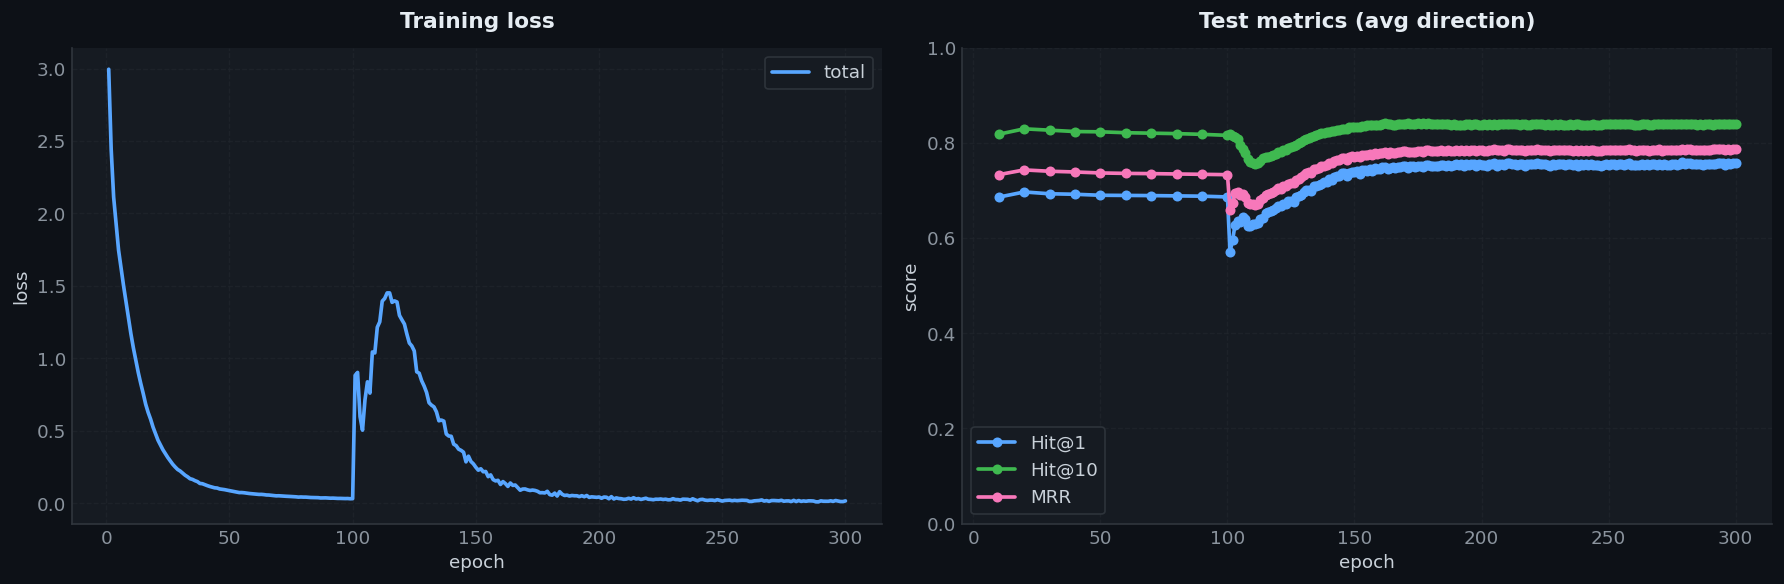

Meilleur Hit@1 = 0.7591 a l'epoque 279


In [15]:
loss_df = pd.read_csv(run_dir / cfg.logging.loss_csv)
met_df  = pd.read_csv(run_dir / cfg.logging.metrics_csv)
display(met_df.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_loss_curves(history["loss_hist"], ax=axes[0], keys=("loss",))
plot_metric_curves(history["metric_hist"], ax=axes[1])
plt.tight_layout(); plt.show()
print(f"Best Hit@1 = {history['best_mrr']:.4f} at epoch {history['best_epoch']}")

---
## 7. Final evaluation and qualitative analysis

In [16]:
ckpt = torch.load(run_dir / "model_best.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
logger.info(f"Best checkpoint reloaded (epoch {ckpt['epoch']}).")
res = trainer.evaluate()
print({k: round(v, 4) for k, v in res.items()})

13:44:33 | INFO    | Meilleur checkpoint recharge (epoque 279).


{'Hit@1': 0.7547, 'Hit@10': 0.8396, 'MRR': 0.7854}


/tmp/ipykernel_229669/3834810464.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(run_dir / "model_best.pt", map_location=device)


### 7.1 Top-3 predictions (refined correspondence S_L) with entity names

In [17]:
model.eval()
with torch.no_grad():
    S_idx, _, S_L = model(trainer.x1, trainer.ai1, trainer.ao1,
                          trainer.x2, trainer.ai2, trainer.ao2)
row = trainer.test_y[0]; col = trainer.test_y[1]
perm = S_L[row].argsort(dim=-1, descending=True)[:, :3]
top3 = torch.gather(S_idx[row], -1, perm).cpu().numpy()
rows = []
for i in range(10):
    s = int(row[i]); g = int(col[i])
    status = "hit@1" if top3[i][0] == g else ("top-3" if g in top3[i] else "miss")
    rows.append({"source": data.names1[s], "gold (en)": data.names2[g],
                 "top-1": data.names2[top3[i][0]], "top-2": data.names2[top3[i][1]],
                 "top-3": data.names2[top3[i][2]], "statut": status})
pd.DataFrame(rows)

,source,gold (en),top-1,top-2,top-3,statut
0,World Touring Car Championship,World Touring Car Championship,World Touring Car Championship,Melbourne Grand Prix Circuit,Okayama International Circuit,hit@1
1,Clone Kerrey County Government,Shire of Cloncurry,County Kerry,Bob Corker,County Carlow,miss
2,Max Hockheimer,Max Horkheimer,Max Horkheimer,Max Scheler,Max Born,hit@1
3,Romania,Romania,Romania,Socialist Republic of Romania,Romania national football team,hit@1
4,Viet namese Dong,Vietnamese dong,Dong Hengyi,Ngô Quang Trưởng,North Vietnam,miss
5,Thomas Cavalier Smith,Thomas Cavalier Smith,Thomas Cavalier Smith,Freeman Freeman Thomas 1st Marquess of Willingdon,University of Sussex,hit@1
6,Madeleine Albright,Madeleine Albright,Madeleine Albright,Catherine Ashton,William Joseph Burns,hit@1
7,Marseille Olympic,Olympique de Marseille,Olympique de Marseille,Île de France,Lyon,hit@1
8,United left wing Spain,United Left Spain,United Left Spain,Real Madrid CF,Atlético Madrid,hit@1
9,Andreas Isaacson cobur Kota,Andreas Prince of Saxe Coburg and Gotha,Andreas Prince of Saxe Coburg and Gotha,Prince Aimone Duke of Aosta,Johannes Thiele chemist,hit@1


---
## 8. Saved artefacts

In [18]:
print("Run dir :", run_dir, "\n")
for p in sorted(run_dir.iterdir()):
    print(f"  {p.name:<22} {p.stat().st_size/1024:8.1f} KB")

Run dir : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/dgmc_zh_en_20260601-134216 

  config_used.yaml            1.0 KB
  loss.csv                    7.2 KB
  loss_curve.png             42.3 KB
  metrics.csv                12.4 KB
  metrics_curve.png          44.5 KB
  model.pt                 3575.9 KB
  model_best.pt            3578.1 KB
  training.txt               21.8 KB


---
## 9. Comparison with the paper (Hits@1)

,Hit@1,Hit@10
modele,,
DGMC (papier),0.8012,0.8747
Ce notebook,0.7547,0.8396


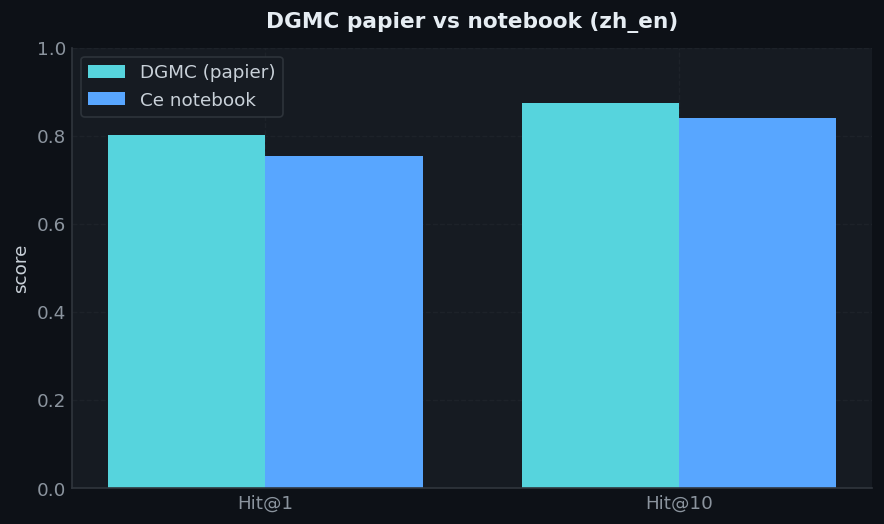

In [19]:
# DGMC paper Table 4 (Hits@1 / Hits@10)
paper_h1  = {"zh_en": 0.8012, "ja_en": 0.8480, "fr_en": 0.9334}.get(cfg.data.pair, float("nan"))
paper_h10 = {"zh_en": 0.8747, "ja_en": 0.8974, "fr_en": 0.9603}.get(cfg.data.pair, float("nan"))
summary_df = pd.DataFrame([
    {"model": "DGMC (paper)", "Hit@1": paper_h1, "Hit@10": paper_h10},
    {"model": "This notebook",   "Hit@1": res["Hit@1"], "Hit@10": res.get("Hit@10", float("nan"))},
]).set_index("model")
display(summary_df.round(4))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
names = ["Hit@1", "Hit@10"]; x = np.arange(len(names)); w = 0.38
ax.bar(x - w/2, [paper_h1, paper_h10], w, label="DGMC (paper)", color=CYCLE[5])
ax.bar(x + w/2, [res["Hit@1"], res.get("Hit@10", np.nan)], w, label="This notebook", color=CYCLE[0])
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1)
style_axes(ax, f"DGMC paper vs notebook ({cfg.data.pair})", None, "score"); ax.legend()
plt.tight_layout(); plt.show()

---
## 10. Notes: what makes DGMC work (debugging lessons)

- **Name features** (sum of GloVe-300d): this is the ingredient that places DGMC well above the
  structural models. Vocabulary coverage ~100% on this split.
- **Cosine + temperature**: the norms of the name features vary enormously (the raw inner
  product gives recall@10 of ~0.13 vs ~0.69 with cosine). We L2-normalise the embeddings and
  score `temperature * cosine` -> S_0 reaches the paper level (~0.68 zh). We keep `S_hat` at
  cosine scale and apply the temperature **only inside the softmax**, otherwise it saturates the
  softmax and kills the refinement gain.
- **dropout 0.2** (not the paper's 0.5): we only run ~100 full-batch steps, 0.5 under-fits.
- **k=25** (not 10): a larger candidate set = more contrastive negatives -> better embeddings
  (recall@10 0.84 vs 0.815). `k=50` makes the refinement **diverge**.
- **detach_refine=false**: we keep training `psi_1` during refinement (the paper freezes it) ->
  the recall of psi_1 keeps rising.
- The **ceiling** of Hits@1 in the sparse model is the recall@k of the initial matching (~0.84
  zh vs ~0.87 paper): that is the ~3 pts left on zh/ja.

**References**
- Fey et al., Deep Graph Matching Consensus, ICLR 2020 - https://arxiv.org/abs/2001.09621
- Xu et al., Cross-lingual KG Alignment via Graph Matching NN (GMNN features), ACL 2019.
- Lample et al., Word Translation Without Parallel Data (cosine + neighbourhood), ICLR 2018.